In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/avazu-ctr-prediction/sampleSubmission.gz
/kaggle/input/avazu-ctr-prediction/train.gz
/kaggle/input/avazu-ctr-prediction/test.gz


## Import Pyspark

In [2]:
!pip install -q pyspark

In [3]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.config("spark.driver.memory", "28g").master('local[*]').appName('Avazu CTR').getOrCreate()
spark.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/06/16 13:16:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Import Library

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.ml.feature import StringIndexer
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import RobustScaler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

## Load the Training Data

total rows : 40428967

In [6]:
total_data = 40428967

# load 10% data
train_df = spark.read.csv('/kaggle/input/avazu-ctr-prediction/train.gz', header=True, inferSchema=True).limit(int(total_data * 0.1))

In [7]:
train_df.printSchema()

root
 |-- id: decimal(20,0) (nullable = true)
 |-- click: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- C1: integer (nullable = true)
 |-- banner_pos: integer (nullable = true)
 |-- site_id: string (nullable = true)
 |-- site_domain: string (nullable = true)
 |-- site_category: string (nullable = true)
 |-- app_id: string (nullable = true)
 |-- app_domain: string (nullable = true)
 |-- app_category: string (nullable = true)
 |-- device_id: string (nullable = true)
 |-- device_ip: string (nullable = true)
 |-- device_model: string (nullable = true)
 |-- device_type: integer (nullable = true)
 |-- device_conn_type: integer (nullable = true)
 |-- C14: integer (nullable = true)
 |-- C15: integer (nullable = true)
 |-- C16: integer (nullable = true)
 |-- C17: integer (nullable = true)
 |-- C18: integer (nullable = true)
 |-- C19: integer (nullable = true)
 |-- C20: integer (nullable = true)
 |-- C21: integer (nullable = true)



In [8]:
# show how many data
train_df.count()

4042896

## Data Preprocessing

In [9]:
# print numerical and categorical columns
numerical_columns = [train_df.dtypes[i] for i in range(len(train_df.dtypes)) if train_df.dtypes[i][1] == 'int' or train_df.dtypes[i][1] == 'double']
categorical_columns = [train_df.dtypes[i] for i in range(len(train_df.dtypes)) if train_df.dtypes[i][1] == 'string']

In [10]:
numerical_columns

[('click', 'int'),
 ('hour', 'int'),
 ('C1', 'int'),
 ('banner_pos', 'int'),
 ('device_type', 'int'),
 ('device_conn_type', 'int'),
 ('C14', 'int'),
 ('C15', 'int'),
 ('C16', 'int'),
 ('C17', 'int'),
 ('C18', 'int'),
 ('C19', 'int'),
 ('C20', 'int'),
 ('C21', 'int')]

In [11]:
categorical_columns

[('site_id', 'string'),
 ('site_domain', 'string'),
 ('site_category', 'string'),
 ('app_id', 'string'),
 ('app_domain', 'string'),
 ('app_category', 'string'),
 ('device_id', 'string'),
 ('device_ip', 'string'),
 ('device_model', 'string')]

### Label Encoding

In [12]:
click_count = train_df[train_df["click"] == 1].count()
no_click_count = train_df[train_df["click"] == 0].count()

In [68]:
print(f'Number of click: {click_count}')
print(f'Number of non-click: {no_click_count}')
print(f'Percentage of click: {click_count / (click_count + no_click_count) * 100}%')
print(f'Percentage of non-click: {no_click_count / (click_count + no_click_count) * 100}%')

Number of click: 703212
Number of non-click: 3339684
Percentage of click: 17.393769218896555%
Percentage of non-click: 82.60623078110345%


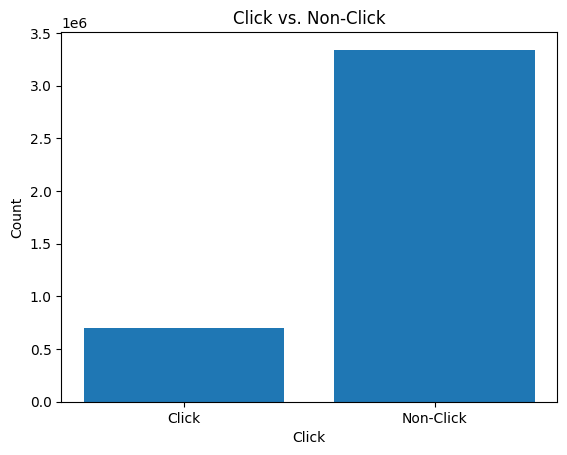

In [13]:
plt.title('Click vs. Non-Click')
plt.bar(['Click', 'Non-Click'], [click_count, no_click_count])
plt.ylabel('Count')
plt.xlabel('Click')
plt.show()

### Categorical Label Encoding

In [14]:
def labelEncoding (df) :
    categorical_columns = [df.dtypes[i] for i in range(len(df.dtypes)) if df.dtypes[i][1] == 'string']

    for col in categorical_columns:
        string_indexer = StringIndexer(inputCol=col[0], outputCol=col[0]+'_index')
        df = string_indexer.fit(df).transform(df)
        df = df.drop(col[0])

    return df

In [15]:
preprocessed_df = labelEncoding(train_df)

In [16]:
# show 10 rows of preprocessed df
preprocessed_df.limit(10).toPandas()

24/06/16 13:23:19 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB


,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,...,C21,site_id_index,site_domain_index,site_category_index,app_id_index,app_domain_index,app_category_index,device_id_index,device_ip_index,device_model_index
0,1000009418151094273,0,14102100,1005,0,1,2,15706,320,50,...,79,1.0,1.0,2.0,0.0,0.0,0.0,0.0,5.0,225.0
1,10000169349117863715,0,14102100,1005,0,1,0,15704,320,50,...,79,1.0,1.0,2.0,0.0,0.0,0.0,0.0,92095.0,9.0
2,10000371904215119486,0,14102100,1005,0,1,0,15704,320,50,...,79,1.0,1.0,2.0,0.0,0.0,0.0,0.0,416105.0,0.0
3,10000640724480838376,0,14102100,1005,0,1,0,15706,320,50,...,79,1.0,1.0,2.0,0.0,0.0,0.0,0.0,118110.0,36.0
4,10000679056417042096,0,14102100,1005,1,1,0,18993,320,50,...,157,51.0,45.0,8.0,0.0,0.0,0.0,0.0,13769.0,16.0
5,10000720757801103869,0,14102100,1005,0,1,0,16920,320,50,...,117,15.0,16.0,1.0,0.0,0.0,0.0,0.0,202568.0,0.0
6,10000724729988544911,0,14102100,1005,0,1,0,20362,320,50,...,157,367.0,289.0,1.0,0.0,0.0,0.0,0.0,2044.0,7.0
7,10000918755742328737,0,14102100,1005,1,1,0,20632,320,50,...,23,2.0,2.0,1.0,0.0,0.0,0.0,0.0,148397.0,14.0
8,10000949271186029916,1,14102100,1005,0,1,2,15707,320,50,...,79,1.0,1.0,2.0,0.0,0.0,0.0,0.0,600060.0,21.0
9,10001264480619467364,0,14102100,1002,0,0,0,21689,320,50,...,23,22.0,0.0,0.0,0.0,0.0,0.0,1.0,1029617.0,58.0


### Get Correlation Matrix

In [17]:
def get_corr (df) :
    vector_col = 'corr_features'
    assembler = VectorAssembler(inputCols=df.columns, outputCol=vector_col)
    df_vector = assembler.transform(df).select(vector_col)

    matrix = Correlation.corr(df_vector, vector_col).collect()[0][0]
    matrix = np.array(matrix.toArray())
    return matrix

In [18]:
corr = get_corr(preprocessed_df)

24/06/16 13:23:53 WARN DAGScheduler: Broadcasting large task binary with size 43.9 MiB
24/06/16 13:23:55 WARN DAGScheduler: Broadcasting large task binary with size 43.9 MiB
24/06/16 13:24:22 WARN DAGScheduler: Broadcasting large task binary with size 43.9 MiB
24/06/16 13:24:24 WARN DAGScheduler: Broadcasting large task binary with size 43.9 MiB
24/06/16 13:24:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


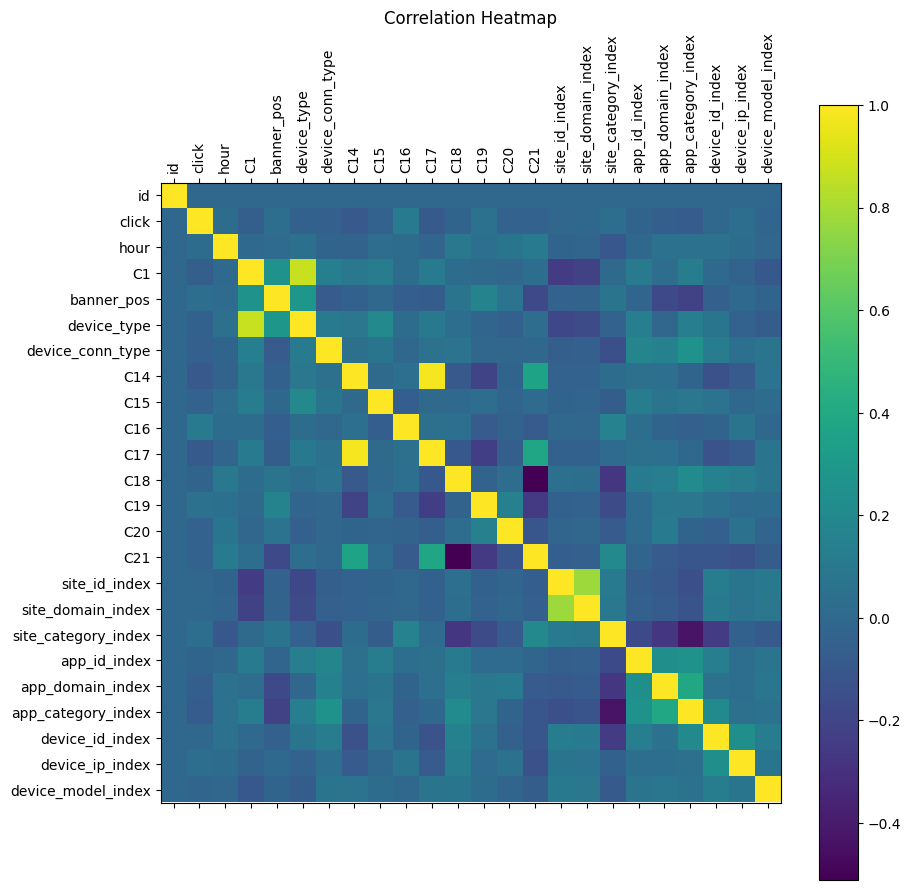

In [19]:
plt.figure(figsize=(10, 10))
plt.matshow(corr, fignum=1)
plt.title('Correlation Heatmap')
plt.xticks(range(len(preprocessed_df.columns)), preprocessed_df.columns, rotation='vertical')
plt.yticks(range(len(preprocessed_df.columns)), preprocessed_df.columns)
plt.colorbar()
plt.show()

### Drop unnecessary columns

In [20]:
def drop_columns (df, collumns_to_drop) :
    for col in collumns_to_drop :
        df = df.drop(col)
    return df

In [21]:
collumns_to_drop = ['id', 'datetime', 'C14']
preprocessed_df = drop_columns(preprocessed_df, collumns_to_drop)

In [22]:
preprocessed_df.printSchema()

root
 |-- click: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- C1: integer (nullable = true)
 |-- banner_pos: integer (nullable = true)
 |-- device_type: integer (nullable = true)
 |-- device_conn_type: integer (nullable = true)
 |-- C15: integer (nullable = true)
 |-- C16: integer (nullable = true)
 |-- C17: integer (nullable = true)
 |-- C18: integer (nullable = true)
 |-- C19: integer (nullable = true)
 |-- C20: integer (nullable = true)
 |-- C21: integer (nullable = true)
 |-- site_id_index: double (nullable = false)
 |-- site_domain_index: double (nullable = false)
 |-- site_category_index: double (nullable = false)
 |-- app_id_index: double (nullable = false)
 |-- app_domain_index: double (nullable = false)
 |-- app_category_index: double (nullable = false)
 |-- device_id_index: double (nullable = false)
 |-- device_ip_index: double (nullable = false)
 |-- device_model_index: double (nullable = false)



### Features Columns

In [23]:
def add_features_column (df) :
    columns = []
    
    for each in df.columns :
        if each != 'click' :
            columns.append(each)
            
    assembler = VectorAssembler(inputCols=columns, outputCol='features')
    df = assembler.transform(df)
    df = df.drop(*columns)
            
    return df

In [24]:
preprocessed_df = add_features_column(preprocessed_df)

In [25]:
preprocessed_df.limit(5).toPandas()

24/06/16 13:24:49 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
24/06/16 13:25:10 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB


,click,features
0,0,"[14102100.0, 1005.0, 0.0, 1.0, 2.0, 320.0, 50...."
1,0,"[14102100.0, 1005.0, 0.0, 1.0, 0.0, 320.0, 50...."
2,0,"[14102100.0, 1005.0, 0.0, 1.0, 0.0, 320.0, 50...."
3,0,"[14102100.0, 1005.0, 0.0, 1.0, 0.0, 320.0, 50...."
4,0,"[14102100.0, 1005.0, 1.0, 1.0, 0.0, 320.0, 50...."


### Normalize Features

In [26]:
def normalize_features (df) :
    scaler = RobustScaler(inputCol='features', outputCol='scaled_features')
    df = scaler.fit(df).transform(df)
    df = df.drop('features')
    df = df.withColumnRenamed('scaled_features', 'features')
    return df

In [27]:
preprocessed_df = normalize_features(preprocessed_df)

24/06/16 13:25:34 WARN DAGScheduler: Broadcasting large task binary with size 43.9 MiB


In [28]:
preprocessed_df.limit(5).toPandas()

24/06/16 13:26:35 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB


,click,features
0,0,"[1410210.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.48..."
1,0,"[1410210.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.48..."
2,0,"[1410210.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.48..."
3,0,"[1410210.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.48..."
4,0,"[1410210.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 3.12..."


## Labeled Point

In [40]:
from pyspark.mllib.regression import LabeledPoint
from pyspark.mllib.linalg import Vectors

# Define the conversion function
def convert_to_labeled_point(row):
    label = row.click
    features = Vectors.dense(row.features.toArray())  # Convert ml.linalg.DenseVector to mllib.linalg.DenseVector
    return LabeledPoint(label, features)

# Apply the conversion
labeled_point_rdd = preprocessed_df.rdd.map(convert_to_labeled_point)

# Take the first 5 elements to inspect them
labeled_point_rdd.take(5)

24/06/16 13:32:52 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB


[LabeledPoint(0.0, [1410210.0,0.0,0.0,0.0,0.0,0.0,0.0,2.4884393063583814,0.0,0.26119402985074625,-9.991507218863966e-06,1.3620689655172413,0.07692307692307693,0.1111111111111111,1.0,0.0,0.0,0.0,0.0,1.895820852512721e-05,1.2162162162162162]),
 LabeledPoint(0.0, [1410210.0,0.0,0.0,0.0,0.0,0.0,0.0,2.4884393063583814,0.0,0.26119402985074625,0.9999900084927812,1.3620689655172413,0.07692307692307693,0.1111111111111111,1.0,0.0,0.0,0.0,0.0,0.34919124282431807,0.04864864864864865]),
 LabeledPoint(0.0, [1410210.0,0.0,0.0,0.0,0.0,0.0,0.0,2.4884393063583814,0.0,0.26119402985074625,0.9999900084927812,1.3620689655172413,0.07692307692307693,0.1111111111111111,1.0,0.0,0.0,0.0,0.0,1.5777210716696115,0.0]),
 LabeledPoint(0.0, [1410210.0,0.0,0.0,0.0,0.0,0.0,0.0,2.4884393063583814,0.0,0.26119402985074625,0.9999900084927812,1.3620689655172413,0.07692307692307693,0.1111111111111111,1.0,0.0,0.0,0.0,0.0,0.4478308017805549,0.1945945945945946]),
 LabeledPoint(0.0, [1410210.0,0.0,1.0,0.0,0.0,0.0,0.0,3.1228323699

## Data Training

### Split Data

In [43]:
train_df, test_df = labeled_point_rdd.randomSplit([0.8, 0.2], seed=11)

In [44]:
print(f'Number of train data: {train_df.count()}')
print(f'Number of test data: {test_df.count()}')

24/06/16 13:33:36 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB


Number of train data: 3234000


24/06/16 13:35:10 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB


Number of test data: 808896


### Model Building

Support Vector Machine

In [45]:
from pyspark.mllib.classification import SVMWithSGD

model = SVMWithSGD.train(train_df)

24/06/16 13:36:40 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB
24/06/16 13:36:42 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB
24/06/16 13:36:48 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB
24/06/16 13:38:47 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB
24/06/16 13:38:49 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB
24/06/16 13:38:52 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB
24/06/16 13:38:54 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB
24/06/16 13:38:57 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB
24/06/16 13:39:00 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB
24/06/16 13:39:03 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB
24/06/16 13:39:05 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB
24/06/16 13:39:08 WARN DAGScheduler: Broadc

### Model Evaluation

In [57]:
model

(weights=[-72431.38043035581,0.0,0.09585888364077927,0.0,0.0,0.0,0.0,-0.6213289556565007,-0.09516024084330263,0.7352813321849607,-0.14901647820605968,-0.32095973545543305,-1.1740456252458704,-0.9048499967359077,0.13231437233471682,-4.028506473351791,-1.6173370192074614,-0.630069762165625,0.0,0.21906973149384834,-0.35422336001579435], intercept=0.0)

In [58]:
predictions = model.predict(test_df.map(lambda p: p.features))
labels_and_predictions = test_df.map(lambda p: p.label).zip(predictions)

In [61]:
from pyspark.sql import Row

# Generate predictions
predictions = test_df.map(lambda lp: Row(label=float(lp.label), prediction=float(model.predict(lp.features))))

# Create DataFrame for evaluation
pred_df = predictions.toDF()

24/06/16 13:51:25 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB


In [64]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(pred_df)
precision = evaluator.evaluate(pred_df, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(pred_df, {evaluator.metricName: "weightedRecall"})
f1 = evaluator.evaluate(pred_df, {evaluator.metricName: "f1"})

print("Accuracy = %s" % (accuracy))
print("Precision = %s" % (precision))
print("Recall = %s" % (recall))
print("F1 = %s" % (f1))


24/06/16 13:56:19 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB
24/06/16 13:57:59 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB
24/06/16 13:59:40 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB
24/06/16 14:01:21 WARN DAGScheduler: Broadcasting large task binary with size 43.8 MiB


Accuracy = 0.8260196613656143
Precision = 0.6823084809625642
Recall = 0.8260196613656143
F1 = 0.7473177812907997
